<a href="https://colab.research.google.com/github/yelenana/machine_learning/blob/main/%22Rybchynska_Olena_HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [86]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [87]:
import sys
import os
path = '/content/drive/MyDrive/ML/2_3'
sys.path.append(path)

from process_bank_churn import preprocess_data

In [88]:
!ls drive/MyDrive/ML/2_3/

Churn_Modelling.csv    __pycache__	      submission_log_reg.csv  train.csv
process_bank_churn.py  sample_submission.csv  test.csv


In [89]:
import pandas as pd
raw_df = pd.read_csv("drive/MyDrive/ML/2_3/Churn_Modelling.csv")
raw_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [90]:
data = preprocess_data(raw_df)

In [91]:
X_train = data['X_train']
train_targets = data['train_targets']
X_val = data ['X_val']
val_targets = data['val_targets']

In [92]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
2151,0.806,0.527027,0.7,0.000000,0.000000,1.0,0.0,0.797394,1.0,0.0,0.0,0.0,1.0
8392,0.778,0.189189,0.3,0.428413,0.000000,1.0,0.0,0.319879,0.0,1.0,0.0,0.0,1.0
5006,0.810,0.256757,0.0,0.477648,0.333333,1.0,1.0,0.586979,0.0,1.0,0.0,1.0,0.0
4117,0.422,0.256757,0.5,0.000000,0.333333,1.0,0.0,0.415448,1.0,0.0,0.0,0.0,1.0
7182,0.684,0.418919,0.6,0.463700,0.333333,0.0,1.0,0.537358,0.0,1.0,0.0,0.0,1.0


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [93]:
import numpy as np
import matplotlib.pyplot as plt

In [94]:
train_with_target = X_train.copy()
train_with_target['Exited'] = train_targets
train_with_target.corr()['Exited'].to_frame().style.background_gradient()

,Exited
CreditScore,-0.033998
Age,0.280378
Tenure,-0.002368
Balance,0.121441
NumOfProducts,-0.054462
HasCrCard,-0.014524
IsActiveMember,-0.152286
EstimatedSalary,0.020260
Geography_France,-0.110837
Geography_Germany,0.182234


Побудую графік між Age та Balance, хоча для Geography_Germany вийшло більше значення, але цей стовпцик бінарний і зрозуміло, що насправді цей сповпчик несе лише 1/3 даних по географії кредиторів

<Axes: xlabel='Age', ylabel='Balance'>

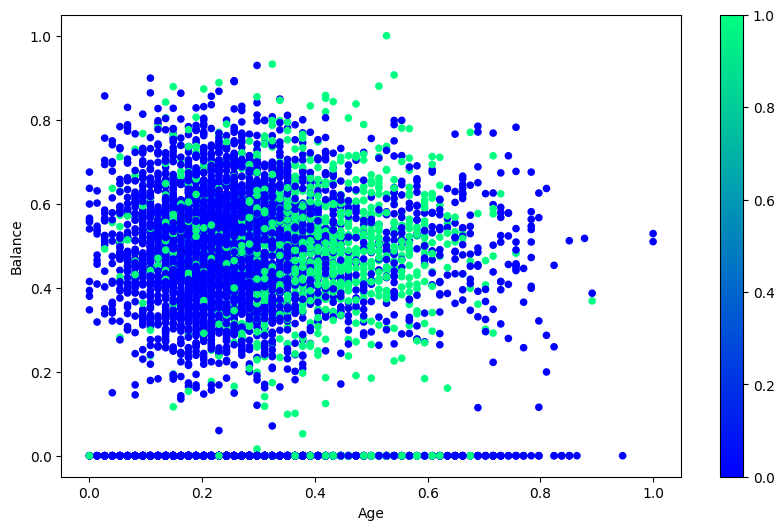

In [95]:
X_train.plot.scatter(
    x='Age',
    y='Balance',
    c=train_targets,
    cmap='winter',
    figsize=(10, 6)
)

На графіку видно, що класи сильно перекриваються, і чіткої межі між ними немає. Ознака Age має помітний вплив — зі збільшенням віку ймовірність відтоку зростає. Ознака Balance має слабший вплив, оскільки точки розподілені хаотично. Отже, дані не є лінійно роздільними, що пояснює, чому складніші моделі (дерева, бустинг) працюють краще.

Модель з параметрами за замовченням:

In [96]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

In [97]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [98]:
# Розраховуємо значення для train i val набрів за допомогою моделі Knn
train_preds_knn = knn.predict_proba(X_train)[:, 1]
val_preds_knn = knn.predict_proba(X_val)[:, 1]

In [99]:
# Оцінюємо результат в порівнянні з реальними даними
train_auc_knn = roc_auc_score(train_targets, train_preds_knn)
val_auc_knn = roc_auc_score(val_targets, val_preds_knn)

print("Train AUROC:", train_auc_knn)
print("Validation AUROC:", val_auc_knn)
print("Gap:", train_auc_knn - val_auc_knn)

Train AUROC: 0.9110667815970181
Validation AUROC: 0.7412127073144023
Gap: 0.1698540742826159


Висновок: отже видно, що Validation AUROC значно нижчий за Train AUROC, що говорить про перенавченість моделі

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [100]:
from sklearn.model_selection import GridSearchCV

In [107]:
param_grid = {'n_neighbors': list(range(1, 25))}

In [108]:
knn_gs = GridSearchCV(knn,param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24]},
             scoring='roc_auc')

In [109]:
knn_best = knn_gs.best_estimator_
print("Найкраще значення гіперпараметра:", knn_gs.best_params_)
print("Кількість найкращих фолдів:", knn_gs.best_score_)

Найкраще значення гіперпараметра: {'n_neighbors': 18}
Кількість найкращих фолдів: 0.762977819726286


In [110]:
knn_gs.best_estimator_

KNeighborsClassifier(n_neighbors=18)

In [111]:
train_preds_knn_best = knn_best.predict_proba(X_train)[:, 1]
val_preds_knn_best = knn_best.predict_proba(X_val)[:, 1]

train_auc_knn_best = roc_auc_score(train_targets, train_preds_knn_best)
val_auc_knn_best = roc_auc_score(val_targets, val_preds_knn_best)

print("Train AUROC:", train_auc_knn_best)
print("Validation AUROC:", val_auc_knn_best)
print("Gap:", train_auc_knn_best - val_auc_knn_best)

Train AUROC: 0.8425774575993682
Validation AUROC: 0.7527728036202613
Gap: 0.08980465397910686


Висновок: розрив між результатом для train та val став невеличкий (0,089), отже модель стала стабільнішою, але значення найближчих сусідів збільшилося з 5 дефолтних аж до 18. Але взагалом, якщо дивитися по валідаційній вибірці, то після застосування GridSearchCV результат покарщився несуттєво, всього з 0.74 до 0.75, і значно поступається результатам, які були отримані для дерева рішень де Validation AUROC склало 0.8452

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [112]:
from sklearn.tree import DecisionTreeClassifier
import time

In [113]:
param_grid = {
    'max_depth': list(range(1, 21, 2)),
    'max_leaf_nodes': list(range(2, 11))
}

dt = DecisionTreeClassifier(random_state=42)

dt_gs = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

start_time = time.time()
dt_gs.fit(X_train, train_targets)
end_time = time.time()

print("Час пошуку гіперпараметрів:", round(end_time - start_time, 4), "сек")
print("Найкращі параметри:", dt_gs.best_params_)
print("Найкращий CV score:", dt_gs.best_score_)

Час пошуку гіперпараметрів: 8.5682 сек
Найкращі параметри: {'max_depth': 5, 'max_leaf_nodes': 10}
Найкращий CV score: 0.811304327123573


In [114]:
dt_best = dt_gs.best_estimator_
dt_best

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=10, random_state=42)

In [115]:
train_auc_dt_best = roc_auc_score(train_targets, dt_best.predict_proba(X_train)[:, 1])
val_auc_dt_best = roc_auc_score(val_targets, dt_best.predict_proba(X_val)[:, 1])

print(f"Train AUROC: {train_auc_dt_best:.4f} | Validation AUROC: {val_auc_dt_best:.4f}")
print(f"Difference (Gap): {abs(train_auc_dt_best - val_auc_dt_best):.4f}")

Train AUROC: 0.8119 | Validation AUROC: 0.8112
Difference (Gap): 0.0007


Висновок: Gap майже нульовий, а AUROC 0,81, хоча якість трохи нижча, ніж при підборі, що був виконаний у темі по деревам прийняття рішень (HW 2.3 Дерева прийняття, там AUROC був ≈ 0.845). Отриманий результ свідчить про відсутність перенавчання та хорошу узагальнюючу здатність моделі.
За допомогою GridSearchCV було виконано пошук оптимальних гіперпараметрів для DecisionTreeClassifier із використанням 3-fold кросвалідації та метрики roc_auc. Час пошуку склав приблизно 5.87 секунд.

Найкращими параметрами в межах заданої сітки виявилися max_depth = 5 та max_leaf_nodes = 10.


4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [117]:
from sklearn.model_selection import RandomizedSearchCV

In [118]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [119]:
dt = DecisionTreeClassifier(random_state=42)

dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=params_dt,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
dt_random.fit(X_train, train_targets)
end_time = time.time()

print(f"Search time: {end_time - start_time:.4f} sec")
print("Best params:", dt_random.best_params_)
print("Best CV score:", dt_random.best_score_)

Search time: 7.0945 sec
Best params: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}
Best CV score: 0.8328095723393291


In [120]:
dt_random_best = dt_random.best_estimator_
dt_random_best

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(16),
                       max_leaf_nodes=np.int64(14), min_samples_leaf=2,
                       min_samples_split=20, random_state=42)

In [121]:
train_auc_dt_random = roc_auc_score(
    train_targets,
    dt_random_best.predict_proba(X_train)[:, 1]
)

val_auc_dt_random = roc_auc_score(
    val_targets,
    dt_random_best.predict_proba(X_val)[:, 1]
)

print(f"Train AUROC: {train_auc_dt_random:.4f} | Validation AUROC: {val_auc_dt_random:.4f}")
print(f"Difference (Gap): {abs(train_auc_dt_random - val_auc_dt_random):.4f}")

Train AUROC: 0.8376 | Validation AUROC: 0.8346
Difference (Gap): 0.0030


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [124]:
test_raw_df = pd.read_csv("drive/MyDrive/ML/2_3/test.csv")

In [125]:
test_raw_df.head(3)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45


In [131]:
from process_bank_churn import preprocess_new_data
X_test = preprocess_new_data(
    test_raw_df,
    input_cols=data['input_cols'],
    scaler=data['scaler'],
    encoder=data['encoder']
)

In [132]:
test_preds = dt_random_best.predict_proba(X_test)[:, 1]
test_preds

array([0.27232143, 0.04147465, 0.18473896, ..., 0.04147465, 0.09986945,
       0.22644928])

In [136]:
submission_file_path = 'drive/MyDrive/ML/2_4/knn/sample_submission.csv'
submission = pd.read_csv(submission_file_path)
submission['Exited']=test_preds
submission.head()

,id,Exited
0,15000,0.272321
1,15001,0.041475
2,15002,0.184739
3,15003,0.394444
4,15004,0.039735


In [137]:
output_filename = 'drive/MyDrive/ML/2_4/knn/submission_log_reg.csv'
submission.to_csv(output_filename, index=False)

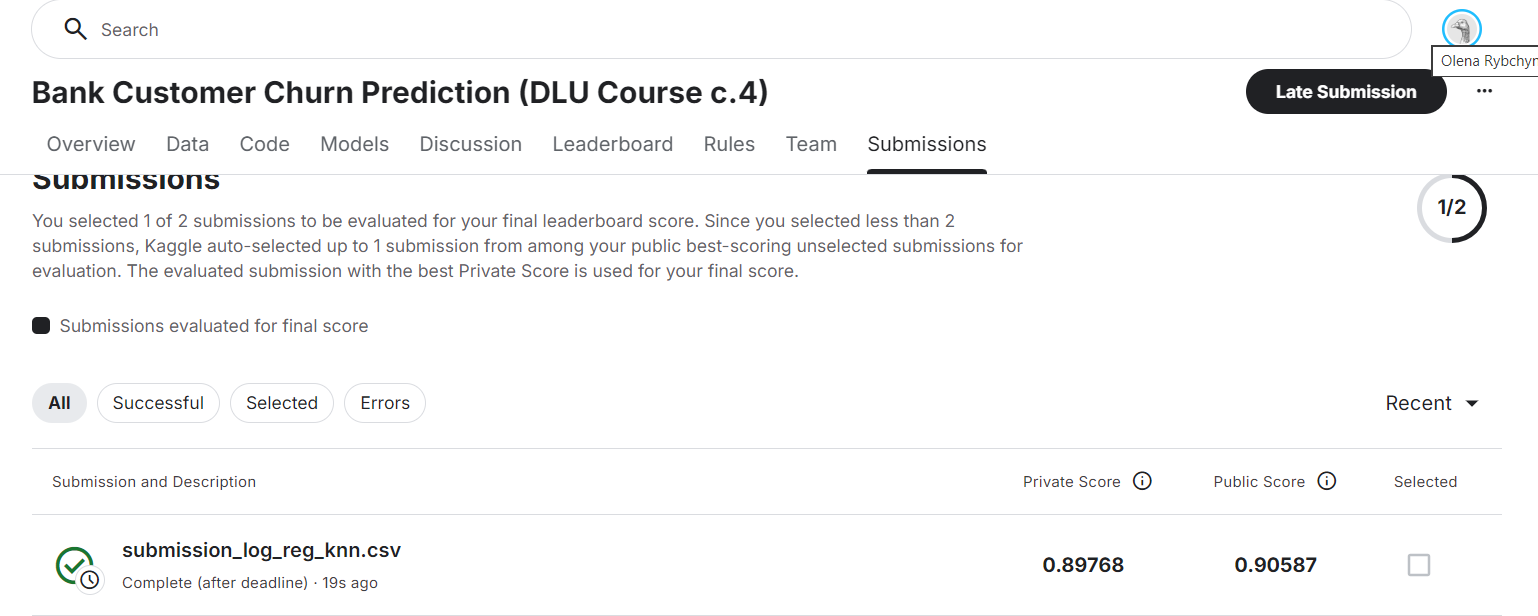

Висновок: DecisionTree модель з мануальним перебором параметрів у мене особисто показала кращі результати, а lgb - й подавно